<a href="https://colab.research.google.com/github/farrelrassya/IntroductionMachineLearningwithpython/blob/main/Practical%20Linear%20Algebra%20for%20Data%20Science/05.Matrices_Part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 5 - Matriks, Bagian 1 (Matrices, Part 1)

Notebook ini membahas dasar-dasar matriks, visualisasi matriks sebagai citra, operasi slicing baris/kolom, jenis-jenis matriks khusus, penjumlahan, shifting, perkalian skalar, dan perkalian Hadamard.

### Identitas Mahasiswa
| Detail | Identitas |
| :--- | :--- |
| **Nama** | Rahmanda Afebrio Yuris Soesatyo |
| **NIM** | 1103223024 |


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# for null spaces
import scipy.linalg

# a pretty-looking matrix from scipy
from scipy.linalg import toeplitz


# NOTE: these lines define global figure properties used for publication.
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg') # print figures in svg format
plt.rcParams.update({'font.size':14}) # set global font size

In [2]:
v = np.array([[1,2,3]]).T # col vector
w = np.array([[10,20]])   # row vector
v + w

array([[11, 21],
       [12, 22],
       [13, 23]])

# Visualisasi Matriks Sebagai Citra


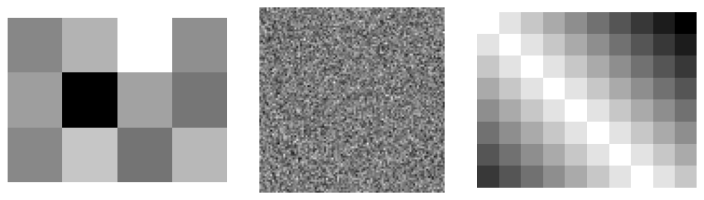

In [3]:
# create some matrices
A = np.random.randn(3,4)
B = np.random.randn(100,100)
C = -toeplitz(np.arange(8),np.arange(10))


# and show them as images
fig,axs = plt.subplots(1,3,figsize=(10,3))

axs[0].imshow(A,cmap='gray')
axs[1].imshow(B,cmap='gray')
axs[2].imshow(C,cmap='gray')

for i in range(3): axs[i].axis('off')
plt.tight_layout()
plt.savefig('Figure_05_01.png',dpi=300)
plt.show()

# Slicing Baris dan Kolom Matriks


In [4]:
# create a matrix
A = np.reshape(np.arange(1,10),(3,3))
print(A)

[[1 2 3]
 [4 5 6]
 [7 8 9]]


In [5]:
# get the n-th row

print( A[1,:] )

# note that to extract only one row, you don't need the column indices. 
print( A[1] )
# But that's potentially confusing, so I recommend avoiding that notation.

[4 5 6]
[4 5 6]


In [6]:
# get the n-th column
print( A[:,1] )
# Note that it prints out as a "row" even thought it's a column of the matrix

[2 5 8]


In [7]:
# multiple rows
A[0:2,:]

array([[1, 2, 3],
       [4, 5, 6]])

In [8]:
# multiple columns
A[:,1:]

array([[2, 3],
       [5, 6],
       [8, 9]])

In [9]:
## extracting a submatrix (multiple rows and cols)

# The goal here is to extract a submatrix from matrix A. Here's A:
# [[1 2 3]
#  [4 5 6]
#  [7 8 9]]

# And we want rows 0-1 and columns 0-1, thus:
# [[1 2]
#  [4 5]]


# seems like this should work...
print( A[0:2,1:2] )
print(' ')

# but this does (remember x:y:z slices from x to y-1 in steps of z)
print( A[0:2:1,0:2:1] )

[[2]
 [5]]
 
[[1 2]
 [4 5]]


In [10]:
# This cell has the example shown in the book.

# the full matrix
A = np.arange(60).reshape(6,10)

# a block of it
sub = A[1:4:1,0:5:1]


# print them out
print('Original matrix:\n')
print(A)

print('\n\nSubmatrix:\n')
print(sub)

Original matrix:

[[ 0  1  2  3  4  5  6  7  8  9]
 [10 11 12 13 14 15 16 17 18 19]
 [20 21 22 23 24 25 26 27 28 29]
 [30 31 32 33 34 35 36 37 38 39]
 [40 41 42 43 44 45 46 47 48 49]
 [50 51 52 53 54 55 56 57 58 59]]


Submatrix:

[[10 11 12 13 14]
 [20 21 22 23 24]
 [30 31 32 33 34]]


# Beberapa Matriks Khusus


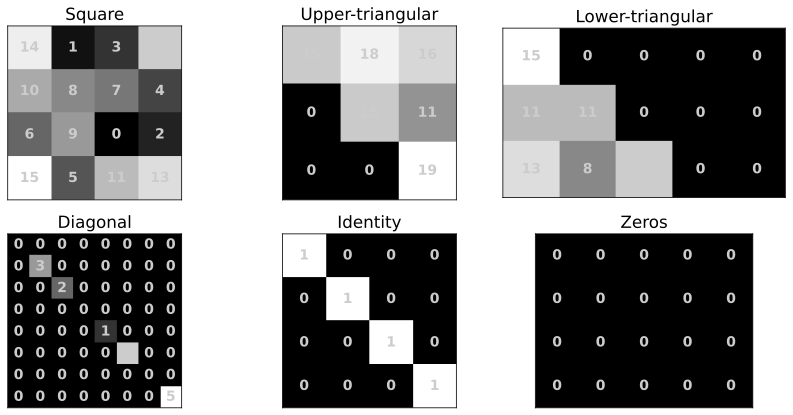

In [11]:
## create some matrices

# square
M1 = np.random.permutation(16).reshape(4,4)

# upper-triangular square
M2 = np.triu(np.random.randint(10,20,(3,3)))

# lower-triangular rectangular
M3 = np.tril(np.random.randint(8,16,(3,5)))

# diagonal
M4 = np.diag( np.random.randint(0,6,size=8) )

# identity
M5 = np.eye(4,dtype=int)

# zeros
M6 = np.zeros((4,5),dtype=int)

matrices  = [ M1,M2,M3,M4,M5,M6 ]
matLabels = [ 'Square','Upper-triangular','Lower-triangular','Diagonal','Identity','Zeros'  ]


_,axs = plt.subplots(2,3,figsize=(12,6))
axs = axs.flatten()

for mi,M in enumerate(matrices):
  axs[mi].imshow(M,cmap='gray',origin='upper',
                 vmin=np.min(M),vmax=np.max(M))
  axs[mi].set(xticks=[],yticks=[])
  axs[mi].set_title(matLabels[mi])
  
  # text labels
  for (j,i),num in np.ndenumerate(M):
    axs[mi].text(i,j,num,color=[.8,.8,.8],ha='center',va='center',fontweight='bold')



plt.savefig('Figure_05_02.png',dpi=300)
plt.tight_layout()
plt.show()

# Detail Lebih Lanjut tentang Matriks Khusus


In [12]:
# matrix size parameters (called 'shape' in Python lingo)
Mrows = 4 # shape 0
Ncols = 6 # shape 1

# create the matrix!
A = np.random.randn(Mrows,Ncols)

# print out the matrix (rounding to facilitate visual inspection)
np.round(A,3)

array([[-0.761, -0.828,  1.587,  1.387,  0.357,  1.462],
       [ 0.147, -0.725, -0.486, -0.205, -2.867,  0.794],
       [ 0.007, -0.425, -0.725, -0.796, -0.481, -0.213],
       [ 0.96 ,  0.75 , -0.106,  0.744,  0.897,  0.49 ]])

In [13]:
# Extract the triangular part of a dense matrix

M = 4
N = 6
A = np.random.randn(M,N)

# upper triangular
print('Upper triangular:\n')
print(np.triu(A))

# lower triangular
print('\n\nLower triangular:\n')
print(np.tril(A))

Upper triangular:

[[ 0.02082723  0.29370887 -0.76374707  0.49267849  0.73313541  1.63904311]
 [ 0.         -0.47152757 -1.09983171  0.74659588  0.21780645  1.30302858]
 [ 0.          0.         -0.0131346   2.92961512 -0.42187681 -0.08521831]
 [ 0.          0.          0.         -0.42052967  1.5312768   0.2395802 ]]


Lower triangular:

[[ 0.02082723  0.          0.          0.          0.          0.        ]
 [-0.15557043 -0.47152757  0.          0.          0.          0.        ]
 [-0.61396152 -0.25929469 -0.0131346   0.          0.          0.        ]
 [ 0.69280497 -1.38405727 -1.76598422 -0.42052967  0.          0.        ]]


In [14]:
# Diagonal

# input a matrix to get the diagonal elements
A = np.random.randn(5,5)
d = np.diag(A)
print('Input a matrix:\n',d)

# OR input a vector to create a diagonal matrix!
v = np.arange(1,6)
D = np.diag(v)
print('\n\nInput a vector:\n',D)

Input a matrix:
 [-0.4153402  -0.01584049 -0.63033043 -1.82023342 -0.14872303]


Input a vector:
 [[1 0 0 0 0]
 [0 2 0 0 0]
 [0 0 3 0 0]
 [0 0 0 4 0]
 [0 0 0 0 5]]


In [15]:
# Identity and zeros matrices

# Note that you only specify one input
n = 4
I = np.eye(n)
print(f'The {n}x{n} identity matrix:\n',I)


The 4x4 identity matrix:
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


In [16]:
# Zeros matrix

# Important: All shape parameters are given as one input (a tuple or list),
#            unlike np.random.randn()
n = 4
m = 5
I = np.zeros((n,m))
print(f'The {n}x{m} zeros matrix:\n',I)

The 4x5 zeros matrix:
 [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


# Penjumlahan Matriks


In [17]:
A = np.array([  [2,3,4],
                [1,2,4] ])

B = np.array([  [ 0, 3,1],
                [-1,-4,2] ])

print(A+B)

[[ 2  6  5]
 [ 0 -2  6]]


# Pergeseran Matriks (Shifting)


In [18]:
# Not shifting; broadcasting scalar addition
3 + np.eye(2)

array([[4., 3.],
       [3., 4.]])

In [19]:
# This is shifting:

# the matrix
A = np.array([ [4,5, 1],
               [0,1,11],
               [4,9, 7]  ])

# the scalar
s = 6

print('Original matrix:')
print(A), print(' ')

# as in the previous cell, this is broadcasting addition, not shifting
print('Broadcasting addition:')
print(A + s), print(' ')

# This is shifting
print('Shifting:')
print( A + s*np.eye(len(A)) )

Original matrix:
[[ 4  5  1]
 [ 0  1 11]
 [ 4  9  7]]
 
Broadcasting addition:
[[10 11  7]
 [ 6  7 17]
 [10 15 13]]
 
Shifting:
[[10.  5.  1.]
 [ 0.  7. 11.]
 [ 4.  9. 13.]]


# Perkalian Skalar Matriks


In [20]:
print(A), print(' ')
print(s*A)

[[ 4  5  1]
 [ 0  1 11]
 [ 4  9  7]]
 
[[24 30  6]
 [ 0  6 66]
 [24 54 42]]


# Perkalian Hadamard (Element-wise)


In [21]:
# two random matrices
A = np.random.randn(3,4)
B = np.random.randn(3,4)

# this is Hadamard multiplication
A*B 

# and so is this
np.multiply(A,B)

# this one is NOT Hadamard multiplication
A@B

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 3 is different from 4)

# Perkalian Matriks Standar


In [22]:
# Create a few matrices
A = np.random.randn(3,6)
B = np.random.randn(6,4)
C = np.random.randn(6,4)

# try some multiplications, and print out the shape of the product matrix
print( (A@B).shape )
print( np.dot(A,B).shape ) # same as above
print( (B@C).shape )
print( (A@C).shape )

(3, 4)
(3, 4)


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 6 is different from 4)

In [23]:
# Note/reminder:

# This is Hadamard (element-wise) multiplication:
print( np.multiply(B,C) ), print(' ')

# This is matrix multiplication
print( np.dot(B,C.T) )

# demonstration:
# np.dot(B,C.T)-B@C.T

[[ 0.22970303 -2.79895597 -1.39625605 -0.19741567]
 [-0.12842696 -1.89454895 -1.27781567  1.2101206 ]
 [-0.05204695  0.48821316 -0.71720501 -0.24473109]
 [-0.069881    0.24233448 -0.75048049 -1.0493427 ]
 [ 0.33132472  0.47030489 -0.41047864  0.79092887]
 [ 0.27907013 -0.78476969 -0.17170646  0.05274949]]
 
[[-4.16292467  1.29977815  0.59162127  0.98686339 -1.07803473  3.46516511]
 [-3.02063567 -2.09067099  0.02708378  0.02234484 -3.79117155  1.56144917]
 [-1.14968545 -3.65921295 -0.5257699  -0.87748546 -3.48690984  0.37974626]
 [ 6.21271742 -1.29036811 -0.53828344 -1.62736971  3.7378641  -4.29116033]
 [ 2.72219914 -1.87889426 -0.53907265 -1.25070522  1.18207984 -1.6049764 ]
 [ 1.51548413  1.18414725 -0.56119583  0.07802913  1.25947    -0.62465653]]


# Geometri Perkalian Matriks-Vektor


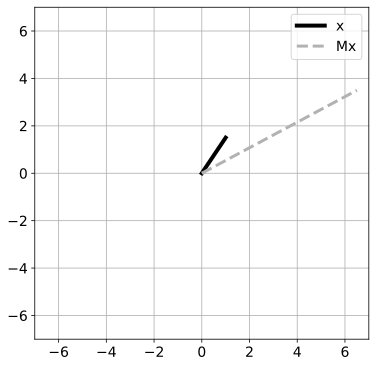

In [24]:
# some matrix
M  = np.array([ [2,3],[2,1] ])
x  = np.array([ [1,1.5] ]).T # transposed into a column vector!
Mx = M@x


plt.figure(figsize=(6,6))

plt.plot([0,x[0,0]],[0,x[1,0]],'k',linewidth=4,label='x')
plt.plot([0,Mx[0,0]],[0,Mx[1,0]],'--',linewidth=3,color=[.7,.7,.7],label='Mx')
plt.xlim([-7,7])
plt.ylim([-7,7])
plt.legend()
plt.grid()
plt.savefig('Figure_05_05a.png',dpi=300)
plt.show()

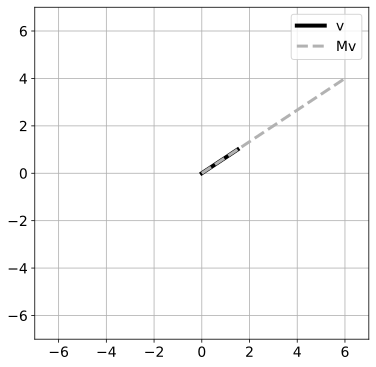

In [25]:
# some matrix
M  = np.array([ [2,3],[2,1] ])
v  = np.array([ [1.5,1] ]).T # transposed into a column vector!
Mv = M@v


plt.figure(figsize=(6,6))

plt.plot([0,v[0,0]],[0,v[1,0]],'k',linewidth=4,label='v')
plt.plot([0,Mv[0,0]],[0,Mv[1,0]],'--',linewidth=3,color=[.7,.7,.7],label='Mv')
plt.xlim([-7,7])
plt.ylim([-7,7])
plt.legend()
plt.grid()
plt.savefig('Figure_05_05b.png',dpi=300)
plt.show()

# Transpose Matriks


In [26]:
# A matrix to transpose
A = np.array([ [3,4,5],[1,2,3] ])

A_T1 = A.T # as method
A_T2 = np.transpose(A) # as function

# double-transpose
A_TT = A_T1.T 


# print them
print( A_T1 ), print(' ')
print( A_T2 ), print(' ')
print( A_TT )

[[3 1]
 [4 2]
 [5 3]]
 
[[3 1]
 [4 2]
 [5 3]]
 
[[3 4 5]
 [1 2 3]]


# Latihan 1

In [27]:
# indexing

A = np.arange(12).reshape(3,4)
print(A)

# find the element in the 2nd row, 4th column
ri = 1
ci = 3

print(f'The matrix element at index ({ri+1},{ci+1}) is {A[ri,ci]}')

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
The matrix element at index (2,4) is 7


# Latihan 2

[[ 0  1  2  3  4  5  6  7  8  9]
 [10 11 12 13 14 15 16 17 18 19]
 [20 21 22 23 24 25 26 27 28 29]
 [30 31 32 33 34 35 36 37 38 39]
 [40 41 42 43 44 45 46 47 48 49]
 [50 51 52 53 54 55 56 57 58 59]
 [60 61 62 63 64 65 66 67 68 69]
 [70 71 72 73 74 75 76 77 78 79]
 [80 81 82 83 84 85 86 87 88 89]
 [90 91 92 93 94 95 96 97 98 99]]
 
[[ 0  1  2  3  4]
 [10 11 12 13 14]
 [20 21 22 23 24]
 [30 31 32 33 34]
 [40 41 42 43 44]]


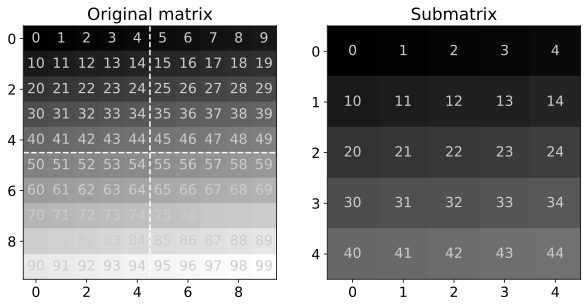

In [28]:
# Create the matrix
C = np.arange(100).reshape((10,10))

# extract submatrix
C_1 = C[0:5:1,0:5:1]

# here's what the matrices look like
print(C), print(' ')
print(C_1)



# visualize the matrices as maps
_,axs = plt.subplots(1,2,figsize=(10,5))

axs[0].imshow(C,cmap='gray',origin='upper',vmin=0,vmax=np.max(C))
axs[0].plot([4.5,4.5],[-.5,9.5],'w--')
axs[0].plot([-.5,9.5],[4.5,4.5],'w--')
axs[0].set_title('Original matrix')
# text labels
for (j,i),num in np.ndenumerate(C):
  axs[0].text(i,j,num,color=[.8,.8,.8],ha='center',va='center')


axs[1].imshow(C_1,cmap='gray',origin='upper',vmin=0,vmax=np.max(C))
axs[1].set_title('Submatrix')
# text labels
for (j,i),num in np.ndenumerate(C_1):
  axs[1].text(i,j,num,color=[.8,.8,.8],ha='center',va='center')


plt.savefig('Figure_05_06.png',dpi=300)
plt.show()

# Latihan 3


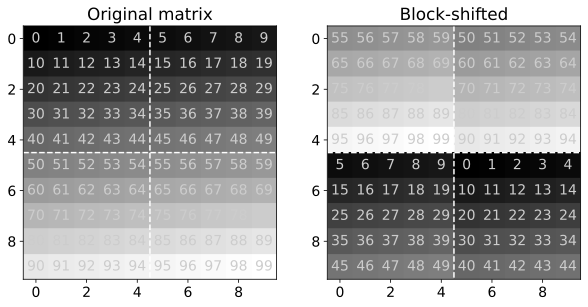

In [29]:
# cut it into blocks
C_1 = C[0:5:1,0:5:1]
C_2 = C[0:5:1,5:10:1]
C_3 = C[5:10:1,0:5:1]
C_4 = C[5:10:1,5:10:1]

# rearrange the blocks
newMatrix = np.vstack( (np.hstack((C_4,C_3)),
                        np.hstack((C_2,C_1))) )


# visualize the matrices
_,axs = plt.subplots(1,2,figsize=(10,5))

axs[0].imshow(C,cmap='gray',origin='upper',vmin=0,vmax=np.max(C))
axs[0].plot([4.5,4.5],[-.5,9.5],'w--')
axs[0].plot([-.5,9.5],[4.5,4.5],'w--')
axs[0].set_title('Original matrix')
# text labels
for (j,i),num in np.ndenumerate(C):
  axs[0].text(i,j,num,color=[.8,.8,.8],ha='center',va='center')


axs[1].imshow(newMatrix,cmap='gray',origin='upper',vmin=0,vmax=np.max(C))
axs[1].plot([4.5,4.5],[-.5,9.5],'w--')
axs[1].plot([-.5,9.5],[4.5,4.5],'w--')
axs[1].set_title('Block-shifted')
# text labels
for (j,i),num in np.ndenumerate(newMatrix):
  axs[1].text(i,j,num,color=[.8,.8,.8],ha='center',va='center')

plt.savefig('Figure_05_07.png',dpi=300)
plt.show()

# Latihan 4

In [30]:
def addMatrices(A,B):

  # check that both matrices have the same size
  if A.shape != B.shape:
    raise('Matrices must be the same size!')

  # initialize sum matrix
  C = np.zeros(A.shape)

  # sum!
  for i in range(A.shape[0]):
    for j in range(A.shape[1]):
      C[i,j] = A[i,j] + B[i,j]
  
  return C


# test the function
M1 = np.zeros((6,4))
M2 = np.ones((6,4))

addMatrices(M1,M2)


array([[1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.]])

# Latihan 5

In [31]:
# create random matrices and a scalar
A = np.random.randn(3,4)
B = np.random.randn(3,4)
s = np.random.randn()

# equations shown in the text
expr1 = s*(A+B)
expr2 = s*A + s*B
expr3 = A*s + B*s


# There are a few ways to test for 3-way equality. 
# My choice below is that if x=y=z, then 2x-y-z=0.

# print out, rounded to 8 digits after the decimal point
print(np.round(2*expr1 - expr2 - expr3,8))

[[ 0. -0.  0.  0.]
 [ 0.  0.  0.  0.]
 [-0.  0.  0.  0.]]


# Latihan 6

In [32]:
# generate two matrices
m = 4
n = 6
A = np.random.randn(m,n);
B = np.random.randn(n,m)

# build up the product matrix element-wise
C1 = np.zeros((m,m))
for rowi in range(m):
  for coli in range(m):
    C1[rowi,coli] = np.dot( A[rowi,:],B[:,coli] )
    


# implement matrix multiplication directly
C2 = A@B

# compare the results (using isclose(); results should be a matrix of TRUEs)
np.isclose( C1,C2 )

array([[ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

# Latihan 7

In [33]:
# Create the matrices
L = np.random.randn(2,6)
I = np.random.randn(6,3)
V = np.random.randn(3,5)
E = np.random.randn(5,2)

# multiplications indicated in the instructions
res1 = ( L@I@V@E ).T
# res2 = L.T @ I.T @ V.T @ E.T
res3 = E.T @ V.T @ I.T @ L.T

# show that res1 and res3 are the same (within rounding error tolerance)
print(res1-res3)

[[-8.88178420e-16  2.66453526e-15]
 [ 4.44089210e-16 -8.88178420e-16]]


# Latihan 8

In [34]:
def isMatrixSymmetric(S):
  
  # difference between matrix and its transpose
  D = S-S.T

  # check whether sum of squared errors (SSE) is smaller than a threshold
  sse = np.sum(D**2)

  # output TRUE if sse is tiny; FALSE means the matrix is asymmetric
  return sse<10**-15

# note: There are many other ways you could solve this. 
# If you want to explore different methods, consider np.all() or np.isclose()

In [35]:
# create symmetric and nonsymmetric matrices
A = np.random.randn(4,4)
AtA = A.T@A

# test!
print(isMatrixSymmetric(A))
print(isMatrixSymmetric(AtA))

False
True


# Latihan 9

In [36]:
# create symmetric and nonsymmetric matrices
A = np.random.randn(4,4)
AtA = (A + A.T) / 2 # additive method!

# test!
print(isMatrixSymmetric(A))
print(isMatrixSymmetric(AtA))

False
True


# Latihan 10

In [37]:
import plotly.graph_objects as go

# As a matrix with two columns in R3, instead of two separate vectors
A = np.array( [ [3,0],
                [5,2],
                [1,2] ] )

# uncomment the line below
# A = np.array( [ [3,1.5],
#                 [5,2.5],
#                 [1, .5] ] )


xlim = [-4,4]
scalars = np.random.uniform(low=xlim[0],high=xlim[1],size=(100,2))

# create random points
points = np.zeros((100,3))
for i in range(len(scalars)):
  points[i,:] = A@scalars[i]

# draw the dots in the figure
fig = go.Figure( data=[go.Scatter3d(x=points[:,0], y=points[:,1], z=points[:,2], mode='markers')])
fig.show()

# Latihan 11

In [38]:
n = 4

# create "base" matrices
O = np.ones((n,n))
D = np.diag(np.arange(1,n+1)**2)
S = np.sqrt(D)

# pre- and post-multiply
pre = D@O
pst = O@D

# and both
both = S@O@S



# print out the "base" matrices
print('Ones matrix:')
print(O), print(' ')

print('Diagonal matrix:')
print(D), print(' ')

print('Sqrt-diagonal matrix:')
print(S), print(' ')



print('Pre-multiply by diagonal:')
print(pre), print(' ')

print('Post-multiply by diagonal:')
print(pst), print(' ')

print('Pre- and post-multiply by sqrt-diagonal:')
print(both)

Ones matrix:
[[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]
 
Diagonal matrix:
[[ 1  0  0  0]
 [ 0  4  0  0]
 [ 0  0  9  0]
 [ 0  0  0 16]]
 
Sqrt-diagonal matrix:
[[1. 0. 0. 0.]
 [0. 2. 0. 0.]
 [0. 0. 3. 0.]
 [0. 0. 0. 4.]]
 
Pre-multiply by diagonal:
[[ 1.  1.  1.  1.]
 [ 4.  4.  4.  4.]
 [ 9.  9.  9.  9.]
 [16. 16. 16. 16.]]
 
Post-multiply by diagonal:
[[ 1.  4.  9. 16.]
 [ 1.  4.  9. 16.]
 [ 1.  4.  9. 16.]
 [ 1.  4.  9. 16.]]
 
Pre- and post-multiply by sqrt-diagonal:
[[ 1.  2.  3.  4.]
 [ 2.  4.  6.  8.]
 [ 3.  6.  9. 12.]
 [ 4.  8. 12. 16.]]


# Latihan 12

In [39]:
# Create two diagonal matrices
N = 5
D1 = np.diag( np.random.randn(N) )
D2 = np.diag( np.random.randn(N) )

# two forms of multiplication
hadamard = D1*D2
standard = D1@D2

# compare them
hadamard - standard

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

---

## Ringkasan dan Pandangan (Summary and Outlook)

### Ringkasan Bab 5

Kita telah mempelajari bagaimana matriks direpresentasikan dalam komputasi dan visualisasi digital, cara mengambil elemen baris/kolom, serta operasi dasar seperti penjumlahan, shifting, perkalian skalar, dan perkalian Hadamard (element-wise).

### Pandangan ke Depan

Selanjutnya, kita akan mempelajari perkalian matriks standar ("standard" matrix multiplication) secara lebih detail dan mendalam beserta geometri transformasinya.
